# Día 4: Probabilidad y Distribuciones

**Business Analytics & Data Science** | EAE Business School | 4 junio 2026

En este notebook vamos a:
1. Estimar probabilidades por simulación y sobre datos reales
2. Calcular probabilidades condicionales
3. Trabajar con distribuciones discretas (uniforme, binomial)
4. Usar la distribución normal con `scipy.stats` (pdf, cdf, ppf)
5. Calcular z-scores y comprobar si los precios son normales

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy import stats

np.random.seed(42)
url = "https://raw.githubusercontent.com/ber2/eae-python/main/data/Houses_Barcelona_samp.csv"
df = pd.read_csv(url)
print("✓ Librerías y datos cargados:", df.shape)

✓ Librerías y datos cargados: (1000, 20)


## Parte 1: Probabilidad por simulación

Lanzamos una moneda justa y observamos la frecuencia de caras.

In [3]:
for n in [10, 100, 10000]:
    lanz = np.random.choice([0, 1], size=n)   # 1 = cara
    print(f"n={n:>6}: P(cara) ≈ {lanz.mean():.3f}")

n=    10: P(cara) ≈ 0.800
n=   100: P(cara) ≈ 0.600
n= 10000: P(cara) ≈ 0.498


**Ley de los grandes números**: con más repeticiones, la frecuencia observada se acerca a la probabilidad teórica (0.5).

## Parte 2: Probabilidad sobre datos reales

Probabilidad de que una propiedad sea de un tipo dado.

In [4]:
total = len(df)
probs = df["type"].value_counts(normalize=True)
print("P(tipo de propiedad):")
for tipo, p in probs.items():
    print(f"  P({tipo:15s}) = {p:.3f}")

P(tipo de propiedad):
  P(Piso           ) = 0.826
  P(Ático          ) = 0.063
  P(Apartamento    ) = 0.032
  P(Planta baja    ) = 0.021
  P(Casa o chalet  ) = 0.020
  P(Dúplex         ) = 0.018
  P(Loft           ) = 0.008
  P(Casa adosada   ) = 0.006
  P(Estudio        ) = 0.005
  P(Finca rústica  ) = 0.001


### Probabilidad condicional

¿Cambia la probabilidad de un piso caro si sabemos que está en el Eixample?

In [5]:
p_cara = (df["price"] > 400000).mean()
eix = df[df["neighborhood"] == "Eixample"]
p_cara_eix = (eix["price"] > 400000).mean()
print(f"P(precio > 400k)            = {p_cara:.3f}")
print(f"P(precio > 400k | Eixample) = {p_cara_eix:.3f}")
print(f"En Eixample es {p_cara_eix/p_cara:.1f}x más probable un piso caro")

P(precio > 400k)            = 0.336
P(precio > 400k | Eixample) = 0.574
En Eixample es 1.7x más probable un piso caro


## Parte 3: Distribuciones discretas

Un dado justo sigue una distribución **uniforme**.

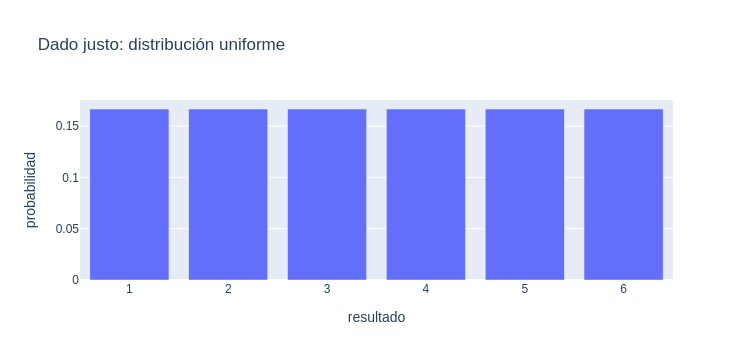

In [6]:
caras = [1,2,3,4,5,6]
px.bar(x=caras, y=[1/6]*6, title="Dado justo: distribución uniforme",
       labels={"x":"resultado","y":"probabilidad"})

### Distribución binomial

Nº de caras en 10 lanzamientos de una moneda justa.

P(exactamente 6 caras) = 0.205
P(6 o más caras)       = 0.377


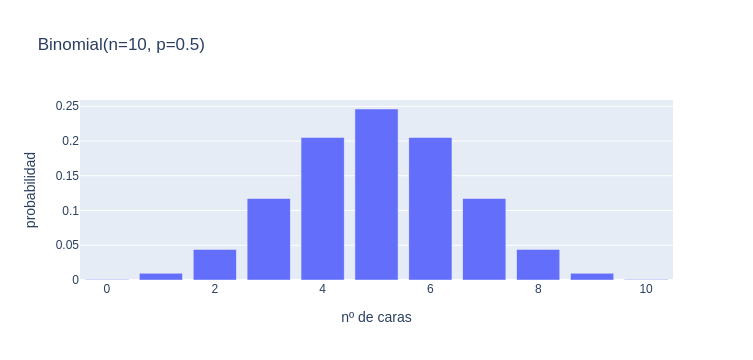

In [7]:
dist = stats.binom(n=10, p=0.5)
print("P(exactamente 6 caras) =", round(dist.pmf(6), 3))
print("P(6 o más caras)       =", round(1 - dist.cdf(5), 3))
ks = list(range(11))
px.bar(x=ks, y=dist.pmf(ks), title="Binomial(n=10, p=0.5)",
       labels={"x":"nº de caras","y":"probabilidad"})

## Parte 4: La distribución normal

`scipy.stats.norm` con pdf, cdf y ppf. Ejemplo: altura de mujeres ~ N(163, 6).

In [8]:
N = stats.norm(loc=163, scale=6)
print("pdf(163)  =", round(N.pdf(163), 4), "(altura de la curva en el centro)")
print("cdf(170)  =", round(N.cdf(170), 3), "→ P(altura ≤ 170)")
print("ppf(0.95) =", round(N.ppf(0.95), 1), "→ percentil 95")

pdf(163)  = 0.0665 (altura de la curva en el centro)
cdf(170)  = 0.878 → P(altura ≤ 170)
ppf(0.95) = 172.9 → percentil 95


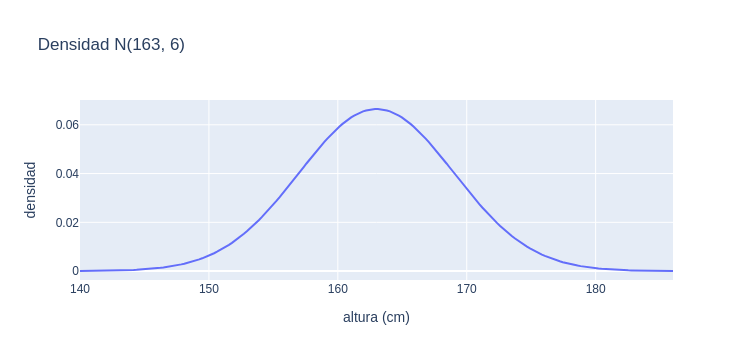

In [9]:
xs = np.linspace(140, 186, 200)
px.line(x=xs, y=N.pdf(xs), title="Densidad N(163, 6)",
        labels={"x":"altura (cm)","y":"densidad"})

## Parte 5: ¿Son normales los precios de Barcelona?

Comprobamos la regla 68-95-99.7 sobre los datos reales.

In [10]:
mu, sigma = df["price"].mean(), df["price"].std()
print(f"Precios ~ aproximación N(μ={mu:,.0f}, σ={sigma:,.0f})\n")
for k in (1, 2, 3):
    dentro = df["price"].between(mu - k*sigma, mu + k*sigma).mean()
    print(f"μ ± {k}σ: {dentro:5.1%}   (una normal esperaría 68/95/99.7%)")

Precios ~ aproximación N(μ=448,640, σ=448,499)

μ ± 1σ: 90.2%   (una normal esperaría 68/95/99.7%)
μ ± 2σ: 95.2%   (una normal esperaría 68/95/99.7%)
μ ± 3σ: 97.7%   (una normal esperaría 68/95/99.7%)


**Conclusión**: los precios **no** son perfectamente normales — tienen asimetría a la derecha (pocos pisos muy caros). Los datos reales rara vez lo son.

### Z-scores: detectar valores extremos

In [11]:
z = stats.zscore(df["price"].dropna())
df_z = df.loc[df["price"].notna()].copy()
df_z["price_z"] = z
extremos = df_z[df_z["price_z"].abs() > 3]
print(f"Propiedades con |z| > 3: {len(extremos)} ({len(extremos)/len(df_z)*100:.2f}%)")
extremos[["neighborhood","type","price","price_z"]].head()

Propiedades con |z| > 3: 21 (2.10%)


,neighborhood,type,price,price_z
62,Eixample,Piso,3500000.0,6.806906
66,Sant Martí,Piso,2200000.0,3.906895
132,Sarrià - Sant Gervasi,Piso,1800000.0,3.014584
178,Les Corts,Ático,3995000.0,7.911141
237,Les Corts,Piso,2800000.0,5.245361


## Resumen

✅ Probabilidad por simulación y la ley de los grandes números
✅ Probabilidad condicional sobre datos reales
✅ Distribuciones discretas: uniforme y binomial (`pmf`, `cdf`)
✅ Distribución normal con `scipy.stats` (`pdf`, `cdf`, `ppf`)
✅ Regla 68-95-99.7 y z-scores

**Mañana**: estadísticos de resumen.